<a href="https://colab.research.google.com/github/bindal-tanmay/AI-Powered-Real-Time-Arrhythmia-Detection-Alert-System/blob/main/ECG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
model_path='/kaggle/ecg_lstm_best.h5'

In [39]:
def live_inference(model_path, port="COM7", baud=115200):
    """
    Reads real-time ECG from Arduino via Serial.
    Collects 187 samples, normalizes, runs LSTM inference.

    Usage:
        live_inference("ecg_lstm_best.h5", port="COM3")   # Windows
        live_inference("ecg_lstm_best.h5", port="/dev/ttyUSB0")  # Linux/Mac
    """
    try:
        import serial
    except ImportError:
        print("Install pyserial: pip install pyserial")
        return

    model = load_model(model_path)
    ser   = serial.Serial(port, baud, timeout=2)
    print(f"\nConnected to Arduino on {port}")
    print("Collecting ECG beats... Press Ctrl+C to stop.\n")

    BEAT_LEN  = 187
    beat_buf  = []
    condition_log = []

    CONDITION_MAP = {
        0: "✅ Normal (N)",
        1: "⚠️  Supraventricular Ectopic (S)",
        2: "🚨 Ventricular Ectopic (V) — HIGH RISK",
        3: "⚠️  Fusion Beat (F)",
        4: "❓ Unknown/Paced (Q)"
    }

    try:
        # Skip header line
        ser.readline()

        while True:
            line = ser.readline().decode('utf-8', errors='ignore').strip()
            if not line or line == "LEADS_OFF":
                if line == "LEADS_OFF":
                    print("⚠️  Leads off — check electrode placement!")
                continue

            parts = line.split(',')
            if len(parts) < 3:
                continue

            try:
                filtered_val = float(parts[1])
                r_peak       = int(parts[2])
            except ValueError:
                continue

            beat_buf.append(filtered_val)

            # Once we have enough samples for one beat window
            if len(beat_buf) >= BEAT_LEN:
                beat = np.array(beat_buf[:BEAT_LEN], dtype=np.float32)

                # Normalize
                beat = (beat - beat.mean()) / (beat.std() + 1e-8)
                beat = beat.reshape(1, BEAT_LEN, 1)   # (1, 187, 1)

                # Inference
                probs   = model.predict(beat, verbose=0)[0]
                cls_idx = np.argmax(probs)
                confidence = probs[cls_idx] * 100

                condition = CONDITION_MAP[cls_idx]
                print(f"Beat → {condition}  (conf: {confidence:.1f}%)")
                print(f"  Probs: { {s: f'{p*100:.1f}%' for s, p in zip(CLASS_SHORT, probs)} }")

                condition_log.append(cls_idx)
                beat_buf = []   # reset buffer

    except KeyboardInterrupt:
        print("\n\nStopped. Session summary:")
        if condition_log:
            from collections import Counter
            counts = Counter(condition_log)
            total  = len(condition_log)
            print(f"  Total beats analyzed: {total}")
            for cls, cnt in sorted(counts.items()):
                print(f"  {CLASS_SHORT[cls]}: {cnt} ({cnt/total*100:.1f}%)")
        ser.close()



Loading MIT-BIH CSV files...
Train: (87554, 187), Test: (21892, 187)


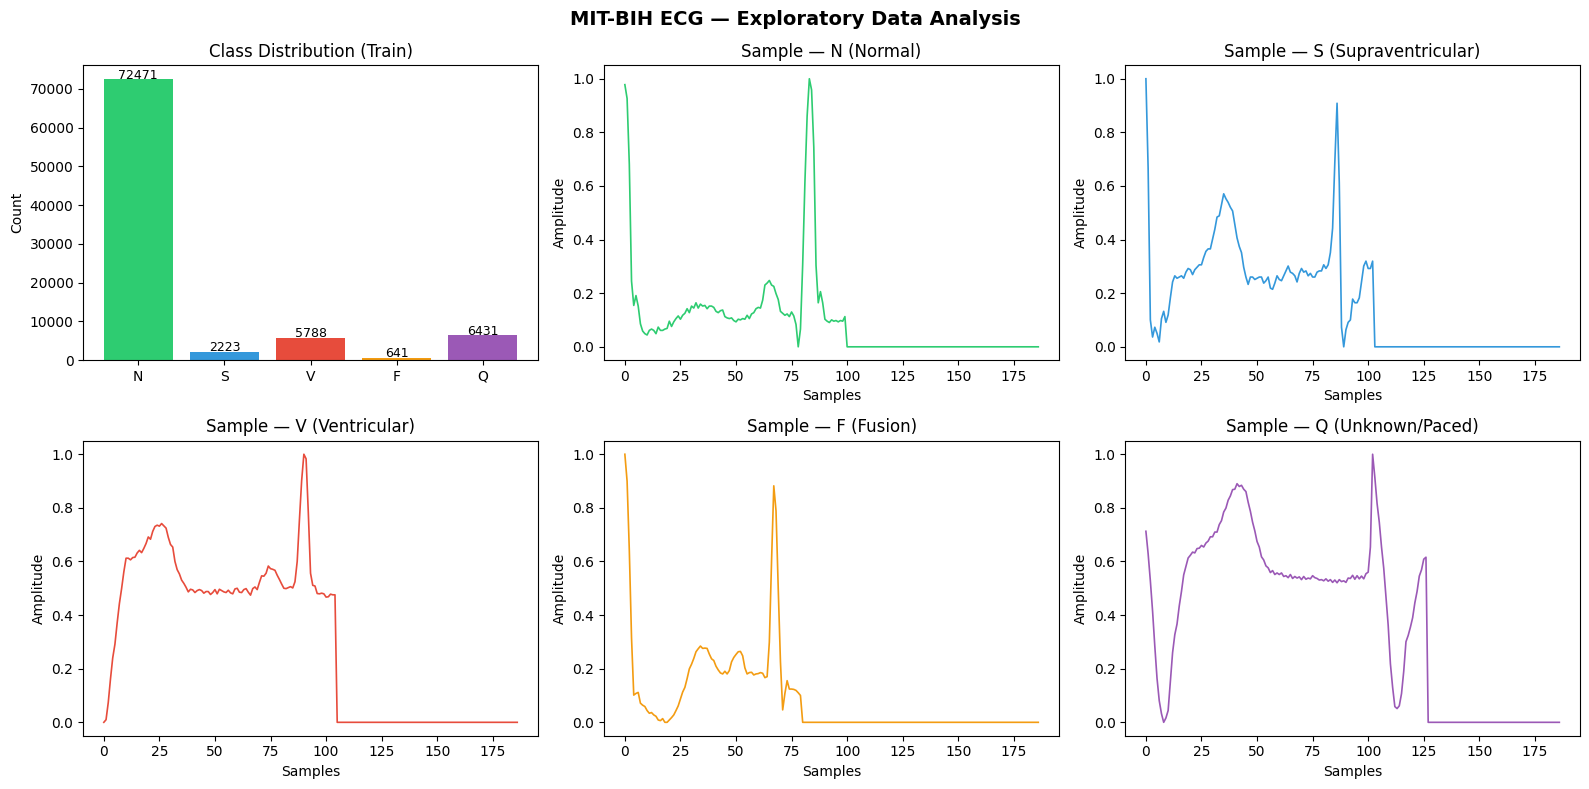

EDA plot saved → eda_plot.png
Class weights: {'N': np.float64(0.24), 'S': np.float64(7.88), 'V': np.float64(3.03), 'F': np.float64(27.32), 'Q': np.float64(2.72)}

Shapes — Train: (74420, 187, 1), Val: (13134, 187, 1), Test: (21892, 187, 1)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, 187, 32)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 187, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 187, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 187, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 93, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 93, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 93, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 93, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 46, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 46, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 46, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 221,829 (866.52 KB)

 Trainable params: 221,253 (864.27 KB)

...

Epoch 1/50
1163/1163 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - accuracy: 0.2521 - auc: 0.6427 - loss: 1.4117
Epoch 1: val_auc improved from None to 0.91288, saving model to ecg_lstm_best.h5



Epoch 1: finished saving model to ecg_lstm_best.h5
1163/1163 ━━━━━━━━━━━━━━━━━━━━ 385s 321ms/step - accuracy: 0.3706 - auc: 0.7484 - loss: 1.1408 - val_accuracy: 0.6448 - val_auc: 0.9129 - val_loss: 0.8174 - learning_rate: 0.0010
Epoch 2/50
1163/1163 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - accuracy: 0.5839 - auc: 0.8718 - loss: 0.7553
Epoch 2: val_auc improved from 0.91288 to 0.95969, saving model to ecg_lstm_best.h5



Epoch 2: finished saving model to ecg_lstm_best.h5
1163/1163 ━━━━━━━━━━━━━━━━━━━━ 376s 316ms/step - accuracy: 0.6305 - auc: 0.8888 - loss: 0.7070 - val_accuracy: 0.8542 - val_auc: 0.9597 - val_loss: 0.5637 - learning_rate: 0.0010
Epoch 3/50
1163/1163 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step - accuracy: 0.7283 - auc: 0.9191 - loss: 0.5798
Epoch 3: val_auc did not improve from 0.95969
1163/1163 ━━━━━━━━━━━━━━━━━━━━ 383s 317ms/step - accuracy: 0.7541 - auc: 0.9299 - loss: 0.5518 - val_accuracy: 0.7070 - val_auc: 0.9211 - val_loss: 0.7829 - learning_rate: 0.0010
Epoch 4/50
1163/1163 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step - accuracy: 0.7855 - auc: 0.9421 - loss: 0.4709
Epoch 4: val_auc did not improve from 0.95969
1163/1163 ━━━━━━━━━━━━━━━━━━━━ 359s 309ms/step - accuracy: 0.7951 - auc: 0.9451 - loss: 0.4756 - val_accuracy: 0.7872 - val_auc: 0.9449 - val_loss: 0.6577 - learning_rate: 0.0010
Epoch 5/50
1163/1163 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step - accuracy: 0.8092 - auc: 0.9528 - loss: 0.4171
Epoch 5


Epoch 5: finished saving model to ecg_lstm_best.h5
1163/1163 ━━━━━━━━━━━━━━━━━━━━ 403s 327ms/step - accuracy: 0.8221 - auc: 0.9565 - loss: 0.4151 - val_accuracy: 0.8144 - val_auc: 0.9637 - val_loss: 0.5141 - learning_rate: 0.0010
Epoch 6/50
1163/1163 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - accuracy: 0.8210 - auc: 0.9579 - loss: 0.3886
Epoch 6: val_auc did not improve from 0.96368
1163/1163 ━━━━━━━━━━━━━━━━━━━━ 369s 316ms/step - accuracy: 0.8294 - auc: 0.9605 - loss: 0.3882 - val_accuracy: 0.7810 - val_auc: 0.9543 - val_loss: 0.5840 - learning_rate: 0.0010
Epoch 7/50
1163/1163 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step - accuracy: 0.8374 - auc: 0.9658 - loss: 0.3503
Epoch 7: val_auc did not improve from 0.96368
1163/1163 ━━━━━━━━━━━━━━━━━━━━ 382s 316ms/step - accuracy: 0.8424 - auc: 0.9671 - loss: 0.3552 - val_accuracy: 0.7947 - val_auc: 0.9630 - val_loss: 0.5180 - learning_rate: 0.0010
Epoch 8/50
1163/1163 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step - accuracy: 0.8381 - auc: 0.9677 - loss: 0.3424
Epoch 8


Epoch 9: finished saving model to ecg_lstm_best.h5
1163/1163 ━━━━━━━━━━━━━━━━━━━━ 373s 321ms/step - accuracy: 0.8551 - auc: 0.9736 - loss: 0.3096 - val_accuracy: 0.8797 - val_auc: 0.9816 - val_loss: 0.3567 - learning_rate: 0.0010
Epoch 10/50
1163/1163 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step - accuracy: 0.8585 - auc: 0.9741 - loss: 0.2935
Epoch 10: val_auc did not improve from 0.98160
1163/1163 ━━━━━━━━━━━━━━━━━━━━ 371s 319ms/step - accuracy: 0.8602 - auc: 0.9747 - loss: 0.3024 - val_accuracy: 0.8381 - val_auc: 0.9687 - val_loss: 0.4727 - learning_rate: 0.0010
Epoch 11/50
1163/1163 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step - accuracy: 0.8578 - auc: 0.9759 - loss: 0.2673
Epoch 11: val_auc did not improve from 0.98160
1163/1163 ━━━━━━━━━━━━━━━━━━━━ 382s 320ms/step - accuracy: 0.8610 - auc: 0.9763 - loss: 0.2816 - val_accuracy: 0.8039 - val_auc: 0.9644 - val_loss: 0.5098 - learning_rate: 0.0010
Epoch 12/50
1163/1163 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step - accuracy: 0.8685 - auc: 0.9786 - loss: 0.2524
Ep

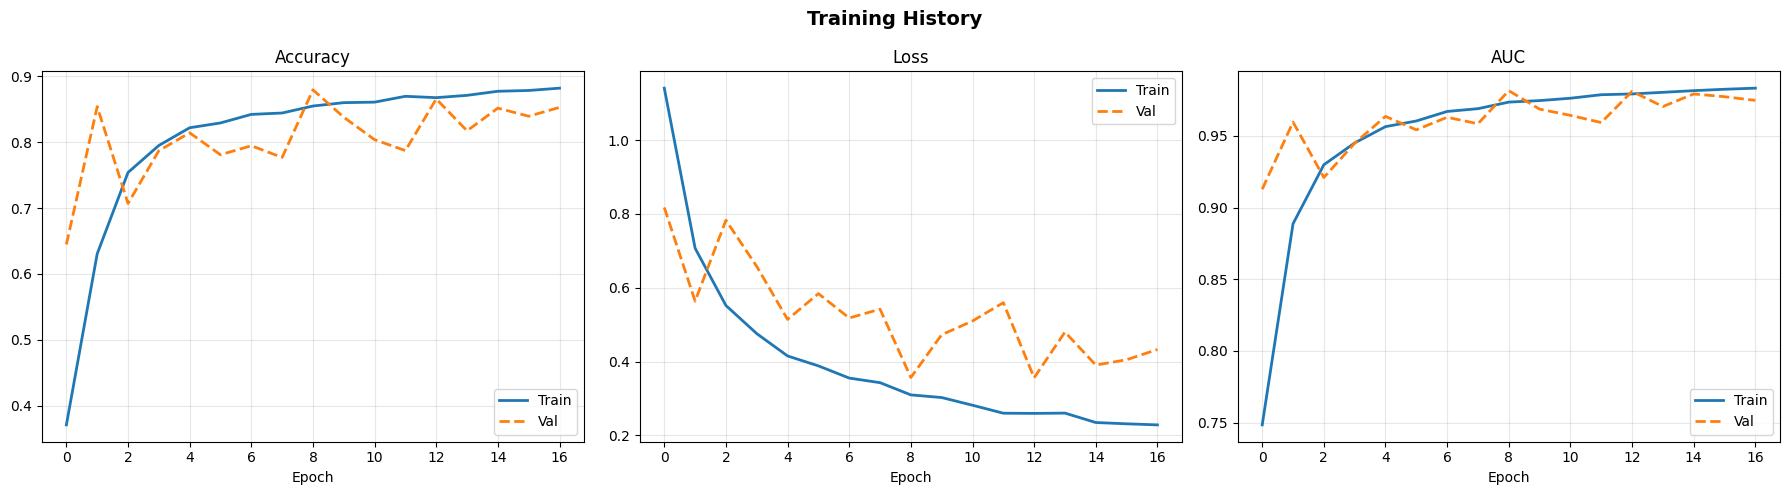

Training history saved → training_history.png

  FULL MODEL EVALUATION

── Classification Report ──────────────────────────────


ValueError: Found input variables with inconsistent numbers of samples: [87554, 21892]

In [40]:
if __name__ == "__main__":

    # ── Step 1: Load data ────────────────────────────────────
    X_train, y_train, X_test, y_test = load_mitbih_csv(DATA_DIR)

    # ── Step 2: EDA ──────────────────────────────────────────
    plot_eda(X_train, y_train)

    # ── Step 3: Preprocess ───────────────────────────────────
    X_tr, X_val, X_te, y_tr, y_val, y_te_cat, class_weights, y_te_raw = \
        preprocess(X_train, y_train, X_test, y_test)

    print(f"\nShapes — Train: {X_tr.shape}, Val: {X_val.shape}, Test: {X_te.shape}")

    # ── Step 4: Build model ──────────────────────────────────
    model = build_model(input_shape=(X_tr.shape[1], 1))

    # ── Step 5: Train ────────────────────────────────────────
    history = train_model(model, X_tr, y_tr, X_val, y_val, class_weights)

    # ── Step 6: Plot history ─────────────────────────────────
    plot_history(history)

    # ── Step 7: Full evaluation ──────────────────────────────
    y_pred, y_prob = evaluate_model(model, X_te, y_te_cat, y_te_raw)

    ── Step 8: Live Arduino inference ───────────────────────
    # Uncomment below when hardware is connected:
    #
    live_inference(
        model_path = MODEL_PATH,
        port       = "COM3",       # Windows → "COM3", "COM4" etc.
    #                                # Linux   → "/dev/ttyUSB0"
    #                                # Mac     → "/dev/cu.usbmodem..."
        baud       = 115200
    )

    print("\nAll done. Model saved at:", MODEL_PATH)


In [41]:
 # ── Step 7: Full evaluation ──────────────────────────────
    y_pred, y_prob = evaluate_model(model, X_te, y_te_cat, y_te_raw)

    # ── Step 8: Live Arduino inference ───────────────────────
    # Uncomment below when hardware is connected:
    #
    # live_inference(
    #     model_path = MODEL_PATH,
    #     port       = "COM3",       # Windows → "COM3", "COM4" etc.
    #                                # Linux   → "/dev/ttyUSB0"
    #                                # Mac     → "/dev/cu.usbmodem..."
    #     baud       = 115200
    # )

    print("\nAll done. Model saved at:", MODEL_PATH)


IndentationError: unexpected indent (1937958964.py, line 2)

In [45]:
    # ── Step 8: Live Arduino inference ───────────────────────
    # Uncomment below when hardware is connected:
    #
    live_inference(
        model_path = MODEL_PATH,
        port       = "COM3",       # Windows → "COM3", "COM4" etc.
    #                                # Linux   → "/dev/ttyUSB0"
    #                                # Mac     → "/dev/cu.usbmodem..."
        baud       = 115200
    )

    print("\nAll done. Model saved at:", MODEL_PATH)

Install pyserial: pip install pyserial

All done. Model saved at: ecg_lstm_best.h5
